<center>
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/ce/Logo-ITM-01.png/1200px-Logo-ITM-01.png" width="300" alt="cognitiveclass.ai logo"  />
</center>

# Notebook: Datos de enfermedades cardíacas de la UCI

## Objetivos


*   Describir las características demográficas y clínicas.
*   Explorar relaciones y asociaciones entre variables relevantes
*  Interpretar los patrones identificados para obtener conclusiones e hipótesis sobre posibles factores de riesgo que influyen en el desarrollo de enfermedad cardíaca

## Tabla de contenido

<div class="alert alert-block alert-info" style="margin-top: 20px">

1.  [Introducción: Objetivos y descripción del dataset](#0)<br>
2.  [Descripción de Variables: Significado y tipo de cada variable](#4) <br>
3.  [Preparación de Datos: Limpieza y revisión de valores faltantes](#2)<br>
4.  [Análisis Exploratorio y Visualización: Estadísticas descriptivas Gráficos y hallazgos principales](#5) <br>
5.  [Conclusiones: Factores relevantes y aprendizajes del análisis](#4) <br>
</div>

# 1. Introducción: Objetivos y descripción del dataset <a id="#1"></a>

In [2]:
import pandas as pd
import numpy as np
file_path = r"/content/drive/MyDrive/heart_disease_uci.csv"
datos = pd.read_csv(file_path)
datos

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


# 2. Descripción de Variables: Significado y tipo de cada variable <a id="#1"></a>

**Age**
Edad del paciente en años.

**Sex**
Sexo del paciente (1 = masculino, 0 = femenino).

**cp**
Tipo de dolor torácico del paciente (categorías como: angina típica, angina atípica, dolor no anginoso, asintomático).

**trestbps**
Presión arterial en reposo medida al ingreso (en mm Hg).

**chol**
Nivel de colesterol sérico (mg/dl).

**fbs**
Azúcar en sangre en ayunas (1 = > 120 mg/dl, 0 = normal).

**restecg**
Resultado del electrocardiograma en reposo (normal o con anomalías).

**thalach**
Frecuencia cardíaca máxima alcanzada durante ejercicio.

**exang**
Angina inducida por ejercicio (1 = sí, 0 = no).

**oldpeak**
Descenso del segmento ST inducido por ejercicio con respecto al reposo (indica isquemia).

**slope**
Pendiente del segmento ST durante el pico del ejercicio (puede indicar cambios isquémicos).

**target**
Indica presencia de enfermedad cardíaca (1 = sí, 0 = no).

# 3. Preparación de Datos: Limpieza y revisión de valores faltantes <a id="#1"></a>

In [3]:
# Reemplazo de símbolos no válidos por NaN
datos.replace("?", np.nan, inplace=True)

Se reemplazaron los símbolos “?” por valores nulos (NaN) para poder identificarlos y gestionarlos correctamente

In [4]:
# Eliminación de columnas con más del 50% de valores faltantes
datos.drop(columns=["ca", "thal"], inplace=True)


Se eliminaron las columnas ca y thal debido a que tenían más del 50 % de datos faltantes, lo cual afecta la calidad y confiabilidad del análisis.

In [5]:
# Eliminación de filas duplicadas
datos.drop_duplicates(inplace=True)

Se eliminaron filas duplicadas para evitar sesgos y asegurar que cada registro represente a un paciente único.

In [6]:
# Reinicio de índices tras eliminación de filas
datos.reset_index(drop=True, inplace=True)

Se reinició el índice para mantener la consistencia del dataframe después de la depuración.

**Comprobación rápida del resultado de la limpieza**

In [7]:
datos.info()
datos.isnull().sum()
datos.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  num       920 non-null    int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 100.8+ KB


(920, 14)

# 4. Análisis Exploratorio y Visualización: Estadísticas descriptivas Gráficos y hallazgos principales <a id="#1"></a>

/tmp/ipython-input-3048914983.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num', data=datos, palette='Set2')


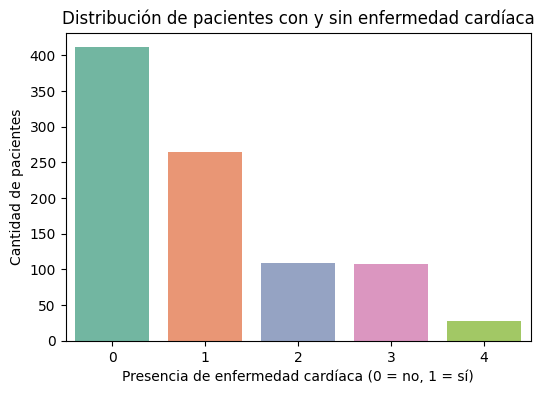

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='num', data=datos, palette='Set2')
plt.title('Distribución de pacientes con y sin enfermedad cardíaca')
plt.xlabel('Presencia de enfermedad cardíaca (0 = no, 1 = sí)')
plt.ylabel('Cantidad de pacientes')
plt.show()

La columna num indica la presencia de enfermedad cardíaca (0 = no, 1 = sí). Este gráfico muestra la proporción de pacientes con y sin enfermedad, lo que nos da una visión general de la distribución en el dataset

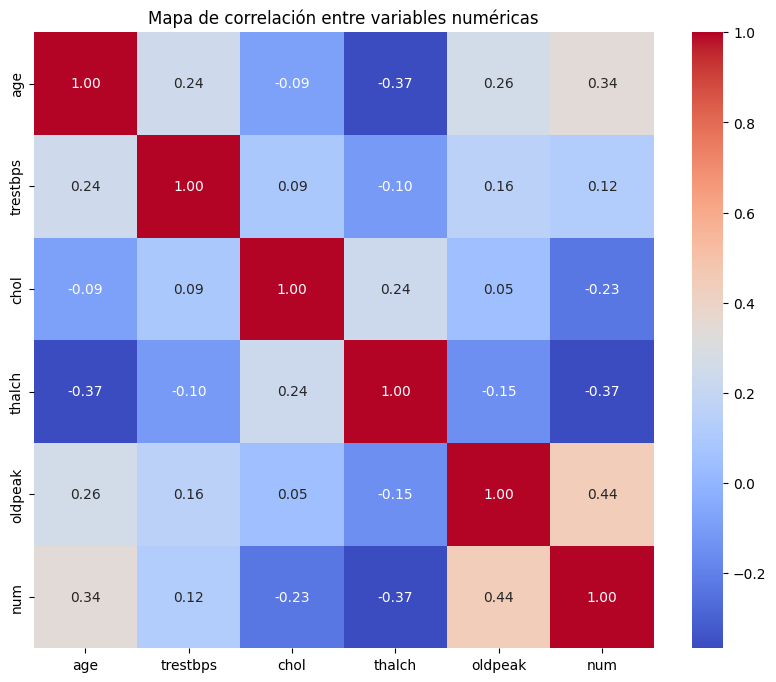

In [11]:
# Selecciono solo variables numéricas relevantes
numericas = datos[['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']]

# Matriz de correlación
corr = numericas.corr()

# Gráfico de calor
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de correlación entre variables numéricas')
plt.show()

Aquí num también entra en la correlación para ver qué variables se relacionan más con la enfermedad cardíaca.

Distribución de edad según presencia de enfermedad cardíaca

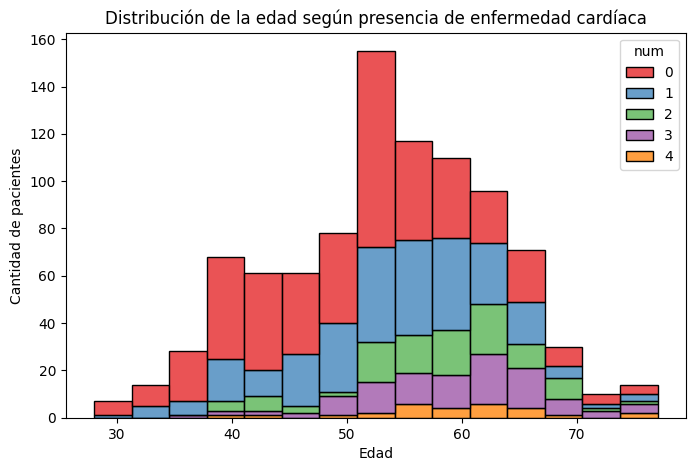

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data=datos, x='age', hue='num', multiple='stack', palette='Set1', bins=15)
plt.title('Distribución de la edad según presencia de enfermedad cardíaca')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pacientes')
plt.show()

Los pacientes con enfermedad cardíaca (num = 1) tienden a concentrarse en edades mayores, mientras que los pacientes sin enfermedad (num = 0) se distribuyen más hacia edades jóvenes. Esto sugiere que la edad puede ser un factor de riesgo importante.

Comparación de presión arterial en reposo (trestbps), colesterol (chol) y frecuencia cardíaca máxima (thalch) según num

/tmp/ipython-input-2739253969.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num', y='trestbps', data=datos, palette='Set2', ax=axes[0])
/tmp/ipython-input-2739253969.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num', y='chol', data=datos, palette='Set2', ax=axes[1])


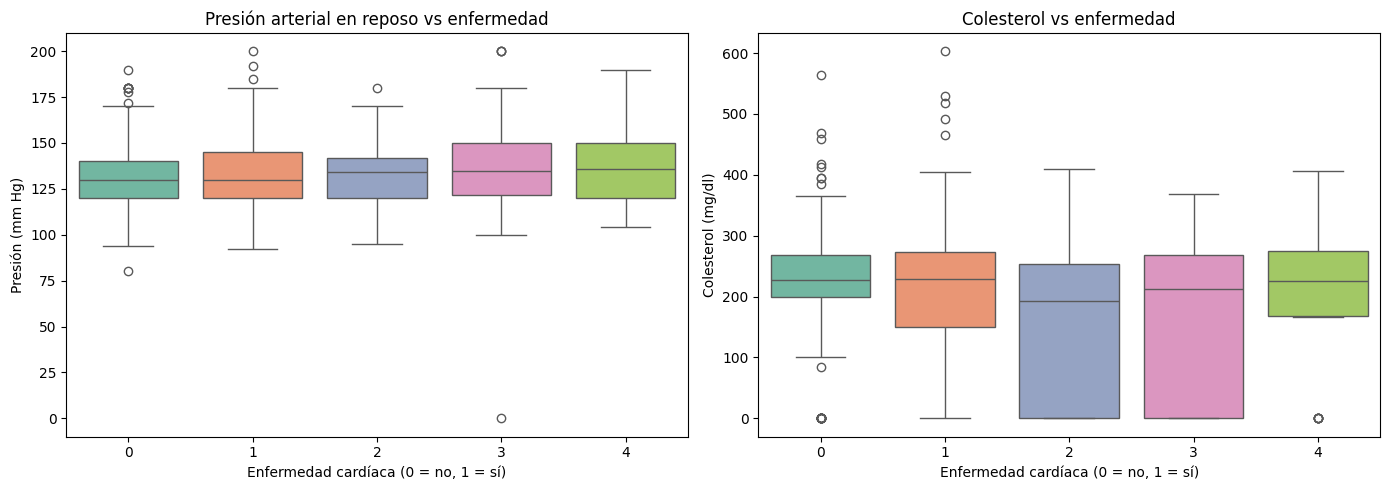

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(x='num', y='trestbps', data=datos, palette='Set2', ax=axes[0])
axes[0].set_title('Presión arterial en reposo vs enfermedad')
axes[0].set_xlabel('Enfermedad cardíaca (0 = no, 1 = sí)')
axes[0].set_ylabel('Presión (mm Hg)')

sns.boxplot(x='num', y='chol', data=datos, palette='Set2', ax=axes[1])
axes[1].set_title('Colesterol vs enfermedad')
axes[1].set_xlabel('Enfermedad cardíaca (0 = no, 1 = sí)')
axes[1].set_ylabel('Colesterol (mg/dl)')

plt.tight_layout()
plt.show()

# 5. Conclusiones: Factores relevantes y aprendizajes del análisis <a id="#1"></a>

La presión arterial en reposo (trestbps) parece ligeramente más alta en pacientes con enfermedad cardíaca.

Los niveles de colesterol (chol) también muestran una tendencia a ser mayores en pacientes con enfermedad.

El análisis exploratorio muestra que los pacientes con enfermedad cardíaca (num = 1) tienden a ser mayores, con mayor presión arterial y niveles de colesterol más altos. Estas variables parecen ser los factores más relevantes asociados a la enfermedad.

Los gráficos y la correlación permiten identificar patrones claros y orientan la selección de variables para futuros análisis o modelos predictivos